# Evaluación 4

**Integrantes:**

+ Integrante 1: Benjamín Alejandro Ibáñez Verdejo : benjamin.ibanez2201@alumnos.ubiobio.cl
+ Integrante 2: Catalina Montserrat Muñoz Durán : catalina.munoz2201@alumnos.ubiobio.cl

**Fecha de Entrega:** 18 Diciembre 2025 antes de las 18:00  


---

## Descripción

Este notebook contiene el desarrollo de la evaluación 4 de la asignatura de Inteligencia Artificial de la carrera Ingeniería Civil en Informática de la Universidad del Biío Bío - Sede Concepción

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (2.2.2)
- numpy (2.0.2)
- matplotlib (3.10.0)
- sklearn (1.6.1)
- seaborn (0.13.2)
- kneed (0.8.5)
- plotly (5.24.1)



---
# Descarga de la data con variables entregadas

In [2]:
# Descargar el archivo y guardarlo en el entorno
!wget https://raw.githubusercontent.com/nutss2635/Trabajos-ramo-ia/refs/heads/Data-E4/clima_biobio.csv

--2025-12-18 17:31:39--  https://raw.githubusercontent.com/nutss2635/Trabajos-ramo-ia/refs/heads/Data-E4/clima_biobio.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 568395 (555K) [text/plain]
Saving to: ‘clima_biobio.csv’

clima_biobio.csv    100%[===================>] 555.07K  --.-KB/s    in 0.05s   

2025-12-18 17:31:39 (10.6 MB/s) - ‘clima_biobio.csv’ saved [568395/568395]



# Descarga de la data usando variables elegidas en la API

In [3]:
!wget https://raw.githubusercontent.com/nutss2635/Trabajos-ramo-ia/refs/heads/Data-E4/data_pt2.csv

--2025-12-18 17:31:44--  https://raw.githubusercontent.com/nutss2635/Trabajos-ramo-ia/refs/heads/Data-E4/data_pt2.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 301476 (294K) [text/plain]
Saving to: ‘data_pt2.csv’

data_pt2.csv        100%[===================>] 294.41K  --.-KB/s    in 0.04s   

2025-12-18 17:31:44 (7.33 MB/s) - ‘data_pt2.csv’ saved [301476/301476]



In [4]:
!pip install kneed

---
# Carga de librerías

In [5]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from kneed import KneeLocator

import plotly.express as px



# Carga de datos

In [6]:
# pequeña vista de la data entregada en adecca
data_parte1 = pd.read_csv("clima_biobio.csv")
data_parte1.head()

,Unnamed: 0,date,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation_probability,uv_index,is_day
0,0,2024-12-09 00:00:00+00:00,14.737500,64.0,12.097788,NaN,0.25,1.0
1,1,2024-12-09 01:00:00+00:00,13.687500,69.0,11.469311,NaN,0.00,0.0
2,2,2024-12-09 02:00:00+00:00,13.087501,72.0,11.046282,NaN,0.00,0.0
3,3,2024-12-09 03:00:00+00:00,12.737500,72.0,10.625299,NaN,0.00,0.0
4,4,2024-12-09 04:00:00+00:00,12.387500,73.0,10.344244,NaN,0.00,0.0


In [7]:
# pequeña vista de la data con variables seleccionadas por el equipo
data_parte2 = pd.read_csv("data_pt2.csv")
data_parte2.head()

,time,temperature_2m (°C),relative_humidity_2m (%),precipitation (mm),wind_speed_10m (km/h)
0,2024-12-09T00:00,13.2,70,0.0,21.9
1,2024-12-09T01:00,12.6,72,0.0,21.6
2,2024-12-09T02:00,12.4,73,0.0,18.2
3,2024-12-09T03:00,11.9,77,0.0,13.6
4,2024-12-09T04:00,11.2,84,0.0,11.3


# PARTE 1 - SEGMENTACION CON VARIABLES ENTREGADAS

## Exploración de datos (EDA)

In [8]:
data_parte1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 8784 non-null   int64  
 1   date                       8784 non-null   object 
 2   temperature_2m             8784 non-null   float64
 3   relative_humidity_2m       8784 non-null   float64
 4   apparent_temperature       8784 non-null   float64
 5   precipitation_probability  4077 non-null   float64
 6   uv_index                   8784 non-null   float64
 7   is_day                     8784 non-null   float64
dtypes: float64(6), int64(1), object(1)
memory usage: 549.1+ KB


Observaciones:
- La data contienen 8784 registros y 8 variables.
- La variable `precipitation_probability` presenta 4707 valores nulos, los cuales deberan ser tratados más adelante con pipeline.

##Tratamiento de datos

In [9]:
data_parte1.dtypes

,0
Unnamed: 0,int64
date,object
temperature_2m,float64
relative_humidity_2m,float64
apparent_temperature,float64
precipitation_probability,float64
uv_index,float64
is_day,float64


In [10]:
data_parte1 = data_parte1.drop(columns=["Unnamed: 0", "date"])

In [11]:
# Eliminamos precipitation_probability debido a que son mas de 4700 nulos que provocan ruido
data_parte1 = data_parte1.drop(columns=["precipitation_probability"])

**Justificación**

A partir de la revisión del tipo de datos `data_parte1.dtypes` y de una vista preliminar del conjunto de datos `data_parte1.head()`, se identifica que las columnas `Unnamed: 0` y `date` no aportan información relevante para el proceso de modelado.

La variable Unnamed: 0 corresponde únicamente a un identificador del registro, mientras que la variable date representa una marca temporal que no contribuye directamente a la predicción ni a la segmentación buscada.

Por este motivo, ambas columnas se eliminan del conjunto de datos antes de aplicar el algoritmo de clustering, con el fin de trabajar únicamente con variables significativas para el análisis.

---

Adicionalmente, a partir del análisis de la estructura del conjunto de datos mediante `data_parte1.info()`, se detectó que la variable `precipitation_probability` presenta más de 4.700 valores nulos, lo que representa más de la mitad de los registros disponibles.

Dado el alto porcentaje de valores faltantes, se decidió eliminar esta variable del análisis, ya que su inclusión podría afectar negativamente la calidad del modelo de clustering y distorsionar la identificación de patrones relevantes en los datos.

---



##Cálculo de métricas: Inercia y Silhouette

In [12]:
# Definimos las variables elegidas
features = ["temperature_2m", "relative_humidity_2m", "apparent_temperature", "uv_index"]
X_graficos = data_parte1[features]

inertias = []
silhouettes = []
range_k = range(2, 11)

print("Calculando métricas para cada k...")

for k in range_k:
    # Creamos un mini-pipeline para cada iteración
    pipeline_iteracion = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=10))
    ])

    # Entrenamos
    pipeline_iteracion.fit(X_graficos)

    # Guardamos la inercia (del modelo kmeans dentro del pipeline)
    inertias.append(pipeline_iteracion.named_steps['kmeans'].inertia_)

    # Para silhouette necesitamos los datos transformados, usamos el pipeline sin el paso final
    pipeline_sin_kmeans = Pipeline(pipeline_iteracion.steps[:-1])
    X_transformado = pipeline_sin_kmeans.transform(X_graficos)
    labels = pipeline_iteracion.named_steps['kmeans'].labels_

    silhouettes.append(silhouette_score(X_transformado, labels))



Calculando métricas para cada k...


**Cálculo de métricas para distintos valores de k**

Con el objetivo de evaluar el comportamiento del algoritmo K-means para distintos números de clusters, se definió un conjunto de variables climáticas continuas que describen el estado atmosférico: temperatura, humedad relativa, temperatura aparente e índice UV.

A partir de estas variables se construyó un conjunto de datos (X_graficos) sobre el cual se entrenaron múltiples modelos K-means, variando el número de clusters en un rango de k = 2 a k = 10.

Para cada valor de k, se utilizó un Pipeline que incluye la imputación de valores faltantes, el escalamiento de las variables y el ajuste del modelo K-means, garantizando una correcta preparación de los datos y evitando sesgos derivados de diferencias de escala.

En cada iteración se calcularon dos métricas de evaluación: la inercia, que mide la compactación interna de los clusters, y el índice silhouette, que evalúa el grado de separación entre los grupos formados. Estas métricas permiten analizar de forma complementaria la calidad de la segmentación obtenida para cada valor de k.

---

##Análisis gráfico del método del codo y del índice silhouette

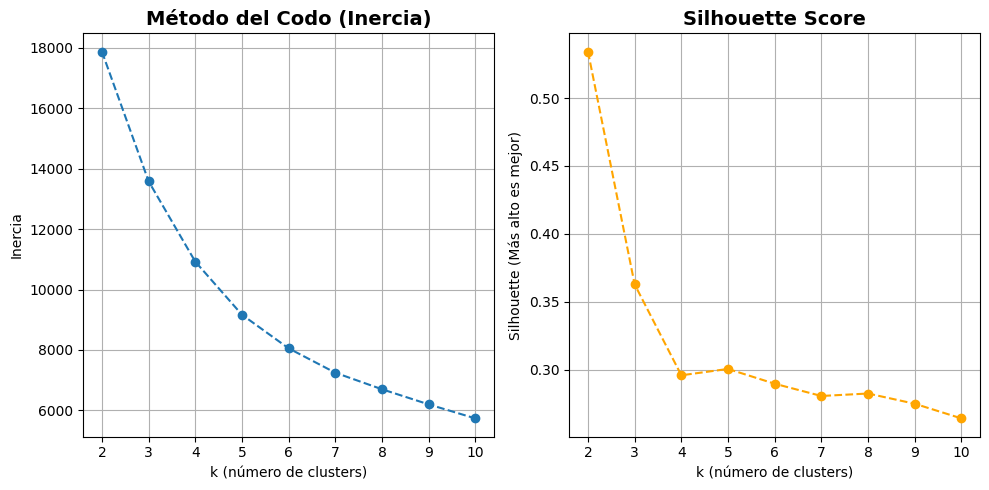

In [13]:
# --- GRÁFICO 1: CODO (INERCIA) ---
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(list(range_k), inertias, marker='o', linestyle='--')
plt.title("Método del Codo (Inercia)", fontsize=14, fontweight="bold")
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia")
plt.xticks(list(range_k))
plt.grid(True)

# --- GRÁFICO 2: SILHOUETTE ---
plt.subplot(1, 2, 2)
plt.plot(list(range_k), silhouettes, marker='o', color='orange', linestyle='--')
plt.title("Silhouette Score", fontsize=14, fontweight="bold")
plt.xlabel("k (número de clusters)")
plt.ylabel("Silhouette (Más alto es mejor)")
plt.xticks(list(range_k))
plt.grid(True)

plt.tight_layout()
plt.show()

## Interpretación de los resultados

### Interpretación del método del codo (Inercia)

En el gráfico del método del codo se observa una reducción pronunciada de la inercia al aumentar el número de clusters desde k = 2 hasta aproximadamente k = 4. A partir de este punto, la curva comienza a suavizarse, indicando que la ganancia en compactación disminuye progresivamente al agregar nuevos clusters.

Este comportamiento sugiere la presencia de un punto de inflexión alrededor de k = 4–5, lo que representa un compromiso razonable entre la complejidad del modelo y la mejora obtenida en la compactación de los clusters.

### Interpretación del índice Silhouette

En el gráfico del índice silhouette se observa que el valor más alto se obtiene para k = 2, lo que indica una separación clara entre dos grandes grupos. No obstante, esta configuración resulta excesivamente general y no permite capturar la diversidad de patrones climáticos presentes en los datos.

Para valores de k entre 4 y 5, el índice silhouette disminuye respecto a k = 2, pero se mantiene en niveles aceptables, con una leve mejora alrededor de k = 5. Esto sugiere una segmentación válida, aunque con cierto grado de superposición entre clusters, lo cual es esperable en datos climáticos continuos.


##Selección de k óptimo

El algoritmo determinó que el codo óptimo está en k = 5


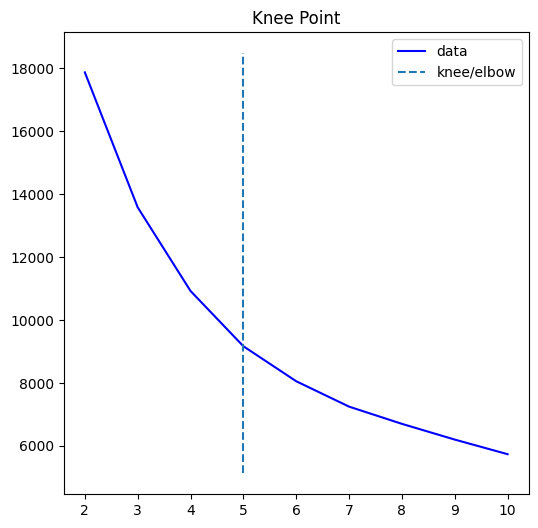

In [ ]:
# --- 1. ENCONTRAR EL K ÓPTIMO AUTOMÁTICAMENTE ---
# Configuramos el localizador del codo
kl = KneeLocator(
    range_k,
    inertias,
    curve="convex",
    direction="decreasing"
)

# Guardamos el K encontrado en una variable
K_ELEGIDO = kl.elbow
print(f"El algoritmo determinó que el codo óptimo está en k = {K_ELEGIDO}")

# Mostramos el gráfico del codo con la línea vertical
kl.plot_knee()
plt.show()

**Selección automática del número óptimo de clusters**

Para la selección del número óptimo de clusters se utilizó el método del codo, implementado mediante el algoritmo KneeLocator, el cual permite identificar de forma automática el punto donde la reducción de la inercia comienza a ser marginal.

Como resultado, el algoritmo determinó un valor óptimo de k = 5, correspondiente al punto de inflexión de la curva de inercia. Este valor coincide con la observación visual del gráfico, donde a partir de cinco clusters la disminución de la inercia deja de ser significativa.

Si bien el índice silhouette presenta su valor máximo para k = 2, dicha configuración resulta excesivamente general para representar la diversidad de patrones climáticos presentes en los datos. En cambio, el valor k = 5 ofrece un equilibrio adecuado entre compactación de los clusters, separación razonable y capacidad de interpretación, por lo que se adopta como configuración final del modelo.

## Entrenamiento del modelo final

In [15]:
# --- 2. PIPELINE FINAL ---
pipeline_final = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=K_ELEGIDO,  # Usamos el K que calculó arriba
        random_state=42,
        n_init=10
    ))
])

# Entrenamos con las columnas seleccionadas
pipeline_final.fit(data_parte1[features])


Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('kmeans',
                 KMeans(n_clusters=np.int64(5), n_init=10, random_state=42))])

**Entrenamiento del modelo final**

Una vez determinado el número óptimo de clusters, se procedió a entrenar el modelo final de K-means utilizando un Pipeline, el cual integra la imputación de valores faltantes, el escalamiento de las variables y el algoritmo de clustering.

Este enfoque garantiza que todas las transformaciones necesarias sean aplicadas de forma consistente y reproducible, permitiendo entrenar el modelo definitivo bajo las mismas condiciones evaluadas previamente durante el análisis de métricas.

In [16]:
# --- 3. GUARDAR RESULTADOS Y PERFILAR ---
# Asignamos las etiquetas al DataFrame original (todo en minúscula 'cluster')
data_parte1['cluster'] = pipeline_final.named_steps['kmeans'].labels_

# Contamos cuántos datos hay en cada grupo
print("\nDistribución de datos por cluster:")
print(data_parte1['cluster'].value_counts())

# Creamos la tabla resumen para interpretar (redondeada a 2 decimales)
cluster_summary = (
    data_parte1
    .groupby('cluster')[features]
    .mean()
    .round(2)
)

print("\n--- PROMEDIOS POR CLUSTER ---")
display(cluster_summary)


Distribución de datos por cluster:
cluster
4    3152
1    2884
0    1004
3     991
2     753
Name: count, dtype: int64

--- PROMEDIOS POR CLUSTER ---


,temperature_2m,relative_humidity_2m,apparent_temperature,uv_index
cluster,,,,
0,14.15,80.30,12.71,5.56
1,11.03,83.17,8.14,0.45
2,21.18,53.18,20.66,6.67
3,16.74,69.25,15.51,1.64
4,13.32,89.00,12.41,0.34


##Características de cada cluster

A partir de la tabla de promedios por cluster, se observa que cada grupo presenta características climáticas diferenciadas en términos de temperatura, humedad relativa, temperatura aparente e índice UV.

* **Cluster 0** se caracteriza por temperaturas moderadas, alta humedad relativa y un índice UV elevado, lo que sugiere condiciones cálidas y húmedas con alta exposición solar.

* **Cluster 1** presenta las temperaturas y temperaturas aparentes más bajas, junto con una humedad elevada y un índice UV muy bajo, representando condiciones frías y nubladas.

* **Cluster 2** corresponde al grupo con las temperaturas más altas y la menor humedad relativa, además de un índice UV alto, lo que indica condiciones cálidas, secas y con fuerte radiación solar.

* **Cluster 3** muestra valores intermedios tanto de temperatura como de humedad, con un índice UV moderado, representando condiciones templadas.

* **Cluster 4** se distingue por una humedad relativa muy alta, temperaturas moderadas y un índice UV bajo, lo que sugiere condiciones húmedas y con escasa radiación solar.

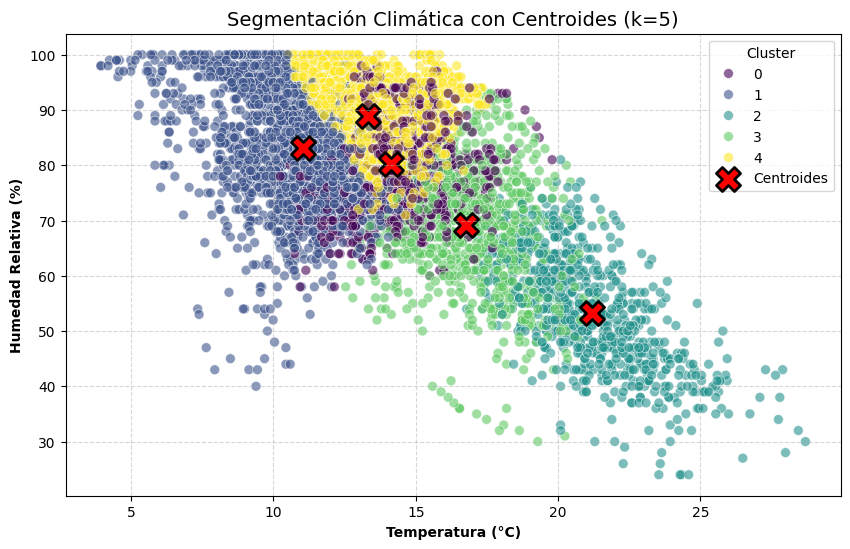

In [17]:
# --- 4. GRAFICAR (SCATTER PLOT) ---
col_x = "temperature_2m"
col_y = "relative_humidity_2m"

# A) RECUPERAR LOS CENTROIDES DEL PIPELINE
# 1. Accedemos a los pasos internos del pipeline ya entrenado
modelo_kmeans = pipeline_final.named_steps['kmeans']
escalador = pipeline_final.named_steps['scaler']

# 2. Sacamos los centros matemáticos (están entre -1 y 1 aprox)
centros_escalados = modelo_kmeans.cluster_centers_

# 3. Los convertimos a valores reales (°C y %) usando el escalador inverso
centros_reales = escalador.inverse_transform(centros_escalados)

# 4. Buscamos en qué posición de la lista 'features' están nuestras columnas X e Y
# Esto es necesario porque 'centros_reales' tiene 4 columnas, hay que elegir las correctas
idx_x = features.index(col_x)
idx_y = features.index(col_y)

# B) CREAR EL GRÁFICO
plt.figure(figsize=(10, 6))

# 1. Pintamos tus puntos (Usando tu estilo con 'sb')
sb.scatterplot(
    data=data_parte1,
    x=col_x,
    y=col_y,
    hue='cluster',
    palette='viridis',
    s=50,
    alpha=0.6
)

# 2. Pintamos los CENTROIDES encima (Las X negras)
plt.scatter(
    centros_reales[:, idx_x], # Coordenada X de los centros
    centros_reales[:, idx_y], # Coordenada Y de los centros
    marker='X',     # La forma de X
    s=300,          # Tamaño grande para que destaque
    c='red',        # Color rojo (o el que quieras)
    edgecolor='black', # Borde negro para contraste
    linewidth=2,
    label='Centroides'
)

plt.xlabel("Temperatura (°C)", fontweight="bold")
plt.ylabel("Humedad Relativa (%)", fontweight="bold")
plt.title(f"Segmentación Climática con Centroides (k={K_ELEGIDO})", fontsize=14)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Interpretación del gráfico**

El gráfico de dispersión de temperatura versus humedad relativa permite visualizar claramente la segmentación climática obtenida mediante K-Means con k=5. Cada cluster se agrupa en zonas específicas del espacio, reflejando patrones climáticos diferenciados. Los centroides confirman los valores promedio observados en la tabla de resumen, mostrando una transición progresiva desde condiciones frías y húmedas hacia condiciones cálidas y secas. En conjunto, el gráfico valida la coherencia del modelo y refuerza la interpretación climática de cada cluster.

---

##Interpretación en el negocio

Se seleccionó el Cluster 2 para su interpretación aplicada, ya que representa condiciones climáticas extremas en comparación con los demás grupos. Este cluster presenta los valores más altos de temperatura y de índice UV, junto con la menor humedad relativa.

Desde una perspectiva aplicada, este tipo de condiciones puede asociarse a escenarios de mayor exposición solar y estrés térmico, lo cual resulta relevante para la planificación de actividades al aire libre, la gestión de riesgos asociados a la radiación UV y la toma de decisiones en sectores como salud pública, agricultura y turismo.

La identificación de este cluster permite anticipar períodos con mayor riesgo climático, facilitando la implementación de medidas preventivas, como alertas tempranas, recomendaciones de protección solar y ajustes en la planificación de actividades sensibles a las condiciones ambientales.

---

##Predicción usando datos nuevos

In [18]:
# --- 5. PREDICCIÓN ---
nuevo_dato = pd.DataFrame([{
    "temperature_2m": 25,
    "relative_humidity_2m": 50,
    "apparent_temperature": 27,
    "uv_index": 8
}])

cluster_predicho = pipeline_final.predict(nuevo_dato)
print(f"\nEl nuevo dato (T = 25°, H = 50%) pertenece al cluster: {cluster_predicho[0]}")


El nuevo dato (T = 25°, H = 50%) pertenece al cluster: 2


# PARTE 2 - SEGMENTACION USANDO VARIABLES EXTRAÍDAS DESDE LA API

## Exploración de datos (EDA)

In [19]:
data_parte2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   time                      8784 non-null   object 
 1   temperature_2m (°C)       8784 non-null   float64
 2   relative_humidity_2m (%)  8784 non-null   int64  
 3   precipitation (mm)        8784 non-null   float64
 4   wind_speed_10m (km/h)     8784 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 343.3+ KB


Observaciones:
- La data presenta 8784 registros y 5 variables.
- No se observan variables con valores nulos.

In [20]:
data_parte2.dtypes

,0
time,object
temperature_2m (°C),float64
relative_humidity_2m (%),int64
precipitation (mm),float64
wind_speed_10m (km/h),float64


In [36]:
data_parte2 = data_parte2.drop(columns=["time"])

In [37]:
data_parte2.head()

,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,cluster
0,13.2,70,0.0,21.9,3
1,12.6,72,0.0,21.6,3
2,12.4,73,0.0,18.2,3
3,11.9,77,0.0,13.6,3
4,11.2,84,0.0,11.3,3


Observaciones:

- Variables numéricas: Las variables críticas para la segmentación (temperature_2m, relative_humidity_2m, precipitation y wind_speed_10m) se encuentran en formatos float64 e int64, lo que permite su procesamiento directo.

- Variable temporal: La columna time es de tipo object. Se identifica que no será utilizada directamente como característica (feature) en el modelo de K-Means, ya que el objetivo es agrupar por condiciones meteorológicas y no por cronología.

Los tipos de datos son consistentes con la información extraída de la API para el periodo de un año solicitado.

## Selección de variables

In [38]:
#primero se estandariza los nombres de las columnas
data_parte2.columns = (
    data_parte2.columns
    .str.lower()
    .str.replace(" ", "_", regex=True)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("°c", "", regex=False)
    .str.replace("%", "", regex=False)
    .str.replace("mm", "", regex=False)
    .str.replace("km/h", "", regex=False)
)
data_parte2.columns = data_parte2.columns.str.rstrip("_")

In [39]:
data_parte2.columns


Index(['temperature_2m', 'relative_humidity_2m', 'precipitation',
       'wind_speed_10m', 'cluster'],
      dtype='object')

In [40]:
features = [
  "temperature_2m",
  "relative_humidity_2m",
  "precipitation",
  "wind_speed_10m"
]
X = data_parte2[features]

Justificación de la selección de variables:

La elección de estas cuatro variables responde a la necesidad de capturar los estados fundamentales de la atmósfera para una segmentación meteorológica completa:

- **temperature_2m:** Es el indicador principal de la energía térmica del sistema, permitiendo diferenciar estaciones y estados de confort térmico.
- **relative_humidity_2m:** Proporciona información sobre la humedad, lo cual es crítico para identificar masas de aire secas vs. saturadas (niebla o proximidad a lluvia).

- **precipitation:** Permite aislar eventos de inestabilidad climática, diferenciando días de operación normal de aquellos que presentan riesgos de interrupción por lluvias.

- **wind_speed_10m:** Representa la dinámica del clima, esencial para identificar condiciones de calma frente a ráfagas intensas, factores que inciden directamente en la seguridad de las tareas al aire libre.

Se decidió excluir la variable time del conjunto de entrenamiento. Al ser un índice secuencial, su inclusión podría confundir al algoritmo K-means, haciendo que agrupe los datos por orden de llegada en lugar de hacerlo por sus características físicas reales.

## Búsqueda del mejor K

In [41]:
# def del rango de cluster a evaluar
inertias = []
silhouettes = []
range_k = range(2, 11)

for k in range_k:
    pipeline_k = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(n_clusters=k, random_state=42))
    ])

    pipeline_k.fit(X)

    # Inercia (desde KMeans)
    inertias.append(pipeline_k.named_steps["kmeans"].inertia_)

    # Silhouette (con datos escalados)
    X_scaled = pipeline_k.named_steps["scaler"].transform(X)
    labels = pipeline_k.named_steps["kmeans"].labels_
    silhouettes.append(silhouette_score(X_scaled, labels))

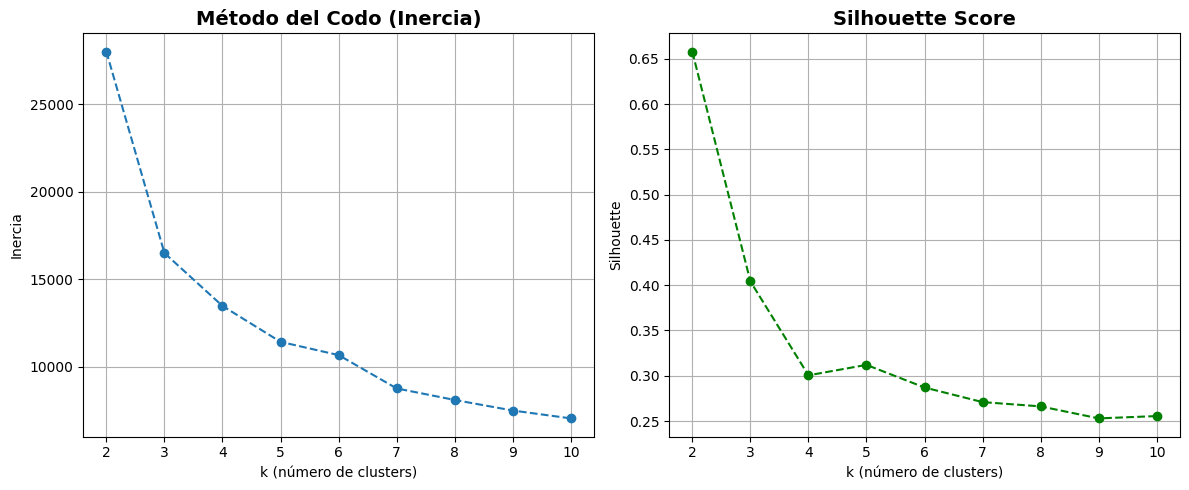

In [42]:
plt.figure(figsize=(12, 5))

# --- GRÁFICO 1: CODO (INERCIA) ---
plt.subplot(1, 2, 1)
plt.plot(list(range_k), inertias, marker='o', linestyle='--')
plt.title("Método del Codo (Inercia)", fontsize=14, fontweight="bold")
plt.xlabel("k (número de clusters)")
plt.ylabel("Inercia")
plt.xticks(list(range_k))
plt.grid(True)

# --- GRÁFICO 2: SILHOUETTE ---
plt.subplot(1, 2, 2)
plt.plot(list(range_k), silhouettes, marker='o', color='green', linestyle='--')
plt.title("Silhouette Score", fontsize=14, fontweight="bold")
plt.xlabel("k (número de clusters)")
plt.ylabel("Silhouette")
plt.xticks(list(range_k))
plt.grid(True)

plt.tight_layout()
plt.show()



Interpretación de los gráficos de selección:
- **Método del Codo (Inercia):** Se observa una disminución drástica de la inercia hasta $k=4$, donde la curva comienza a estabilizarse (punto de inflexión). Esto indica que añadir más clusters no aporta una mejora significativa en la compactación de los grupos.

- **Silhouette Score:** El gráfico muestra que para $k=4$ se obtiene un equilibrio entre cohesión y separación. 5Un valor de 0.30 indica que, aunque existe cierta complejidad en los datos climáticos extraídos de la API, la estructura de los 4 clusters es consistente y válida para el análisis.

El algoritmo determinó que el codo óptimo está en k = 4 



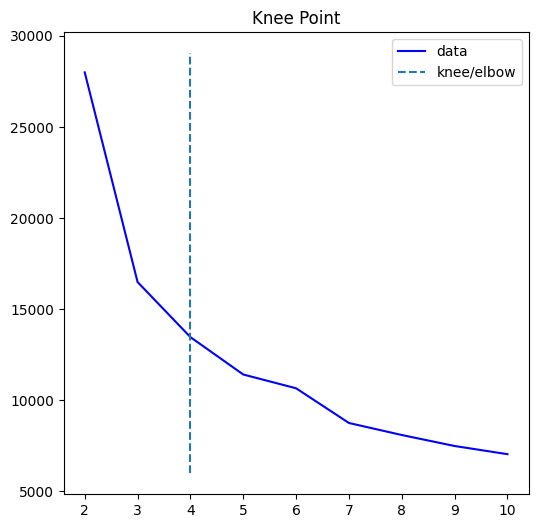

In [43]:
# Obtiene el mejor valor de k
kl = KneeLocator(range_k, inertias, curve="convex", direction="decreasing")
print(f"El algoritmo determinó que el codo óptimo está en k = {kl.elbow} \n")

# Mostramos el gráfico del codo con la línea vertical
kl.plot_knee()
plt.show()

Justificación:

Para evitar sesgos manuales, se utilizó la librería $KneeLocator$, la cual confirmó que el "codo" de la curva se encuentra en k=4.

## Entrenamiento del modelo final

In [44]:
k_optimo = kl.elbow

pipeline_final = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=k_optimo, random_state=42))
])

pipeline_final.fit(X)
data_parte2["cluster"] = pipeline_final.predict(X)

data_parte2.head()


,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,cluster
0,13.2,70,0.0,21.9,3
1,12.6,72,0.0,21.6,3
2,12.4,73,0.0,18.2,3
3,11.9,77,0.0,13.6,3
4,11.2,84,0.0,11.3,3


Justificaciones:

- Uso de Pipeline: Se integró el escalamiento (StandardScaler) y el algoritmo (KMeans) en un único flujo de trabajo. Esto asegura que las transformaciones de datos se apliquen de manera consistente y evita errores de sesgo en el agrupamiento.

- Escalamiento de Variables: Dado que las variables meteorológicas (temperatura, humedad, presión/viento) poseen diferentes unidades y magnitudes, el uso de un escalador es indispensable para que el algoritmo de K-means no priorice injustamente a las variables con valores numéricos más altos.

- Selección de k: El valor de k no fue definido de forma arbitraria. Se evaluaron distintos valores de k mediante el método del codo y la métrica silhouette, seleccionándose a través de KneeLocator $k=4$ al identificarse como el punto de inflexión de la curva de inercia.


## 1. Métricas de evaluación

In [45]:
X_scaled = pipeline_final.named_steps["scaler"].transform(X)
labels = pipeline_final.named_steps["kmeans"].labels_

silhouette = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)

print(f"{'Silhouette Score':<25}: {silhouette:.4f}")
print(f"{'Calinski-Harabasz':<25}: {ch:.4f}")
print(f"{'Davies-Bouldin':<25}: {db:.4f}")


Silhouette Score         : 0.3005
Calinski-Harabasz        : 4708.7644
Davies-Bouldin           : 1.0857


Interpretación de las métricas:
- Los resultados obtenidos a partir de las métricas de evaluación indican que el modelo de segmentación presenta un desempeño adecuado para un problema no supervisado. El Silhouette Score (0.3005), aunque no es alto, es positivo, lo que sugiere que las observaciones están razonablemente bien asignadas a sus respectivos clusters, existiendo una separación aceptable entre ellos.

- El índice de Calinski-Harabasz (4708.76) presenta un valor elevado, lo cual indica que los clusters formados son compactos internamente y muestran una buena separación entre grupos, reforzando la coherencia de la segmentación obtenida.

- El índice de Davies-Bouldin (1.0857) se mantiene en un rango moderado, lo que sugiere que, si bien existe cierta cercanía entre algunos clusters, la estructura general del agrupamiento es consistente y no presenta solapamientos excesivos.

Estas métricas permiten concluir que el modelo K-means logra identificar patrones relevantes en los datos, generando una segmentación válida y coherente para el análisis exploratorio realizado.

## 2. Características de cada cluster

In [51]:
cluster_summary = data_parte2.groupby("cluster")[features].mean()
cluster_summary


,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
cluster,,,,
0,12.080447,94.497207,3.504469,24.430168
1,10.358194,90.661456,0.025822,6.156253
2,18.972091,56.953660,0.001527,14.412112
3,13.658178,79.998331,0.073932,13.431509


Interpretación de los perfiles meteriológicos de los 4 clusters:

**Cluster 0:** Se caracteriza por temperaturas bajas, humedad extremadamente alta, precipitaciones elevadas y vientos intensos. Este grupo representa condiciones climáticas adversas, típicas de días fríos, muy húmedos y lluviosos, acompañados de viento fuerte.

**Cluster 1:** Presenta las temperaturas más bajas, alta humedad, pero precipitaciones prácticamente nulas y vientos débiles. Corresponde a condiciones frías y estables, sin eventos meteorológicos relevantes como lluvia o viento intenso.

**Cluster 2:** Destaca por las temperaturas más altas, baja humedad relativa, ausencia de precipitaciones y vientos moderados. Este cluster representa condiciones cálidas y secas, asociadas a días despejados y estables.

**Cluster 3:** Muestra temperaturas moderadas, humedad alta, precipitaciones leves y vientos moderados. Puede interpretarse como un escenario intermedio o de transición, sin extremos marcados en las variables climáticas.

Los clusters obtenidos permiten identificar patrones climáticos bien definidos, diferenciando escenarios lluviosos, fríos, cálidos y condiciones intermedias, lo que demuestra una segmentación coherente y útil del conjunto de datos.

## 3. Gráfica para mostrar los cluster

In [47]:
centroides = data_parte2.groupby("cluster")[[
    "temperature_2m",
    "relative_humidity_2m",
    "wind_speed_10m"
]].mean().reset_index()

fig = px.scatter_3d(
    data_parte2,
    x="temperature_2m",
    y="relative_humidity_2m",
    z="wind_speed_10m",
    color="cluster",
    opacity=0.6
)

fig.update_traces( marker=dict(size=5), showlegend=True )
fig.update_layout(coloraxis_showscale=True)
fig.add_scatter3d(
    x=centroides["temperature_2m"],
    y=centroides["relative_humidity_2m"],
    z=centroides["wind_speed_10m"],
    mode="markers",
    marker=dict(size=20, color="black", symbol="cross"), name="Centroides" )

fig.update_layout( title="Clusters climáticos con centroides (3D)",
    legend=dict(
        x=0.02,
        y=0.95,
        bgcolor="rgba(255,255,255,0.8)"),
    scene=dict(
        xaxis_title="Temperatura (°C)",
        yaxis_title="Humedad (%)",
        zaxis_title="Velocidad del viento (km/h)"))
fig.show()

Interpretación del gráfico 3D:

Permite visualizar cómo las variables de temperatura, humedad y velocidad del viento interactúan para formar grupos distintos. Los Centroides (marcados con X) representan el "punto medio" de cada estado climático identificado. La separación espacial en el eje de la Humedad y Temperatura confirma que el modelo ha logrado distinguir exitosamente entre días secos/cálidos y días húmedos/fríos.

## 4. Interpretación en el negocio

Se decidió realizar la interpretación en el negocio del Cluster 0. Este representa condiciones climáticas caracterizadas por bajas temperaturas, humedad extremadamente alta, precipitaciones significativas y vientos intensos. Este tipo de escenario es especialmente relevante desde el punto de vista operativo y de planificación.

Desde una perspectiva de negocio o toma de decisiones, este cluster puede asociarse a condiciones climáticas adversas, que podrían impactar negativamente en actividades sensibles al clima, como la construcción, la agricultura o eventos al aire libre. La identificación de este cluster permite anticipar riesgos asociados a lluvias intensas y viento fuerte, facilitando la planificación preventiva y la asignación de recursos.

Este cluster resulta importante para la gestión de riesgos climáticos, ya que permite reconocer patrones meteorológicos que requieren mayor atención y medidas de mitigación frente a posibles interrupciones operacionales.

## 5. Predicción usando datos nuevos

In [48]:
def predecir_cluster(nuevos_valores: dict, pipeline_entrenado):
    """
    Toma un diccionario con datos meteorológicos nuevos, los convierte
    en DataFrame para mantener los nombres de las columnas y utiliza el
    pipeline entrenado para escalar y predecir el cluster correspondiente.
    """
    df_nuevo = pd.DataFrame([nuevos_valores])
    cluster = pipeline_entrenado.predict(df_nuevo)
    return cluster[0]

**Caso 1:** día frío y lluvioso 🌧

In [49]:
nuevo_registro = {
    "temperature_2m": 7,
    "relative_humidity_2m": 95,
    "precipitation": 20,
    "wind_speed_10m": 35
}

cluster_predicho = predecir_cluster(nuevo_registro, pipeline_final)
print(f"El nuevo registro pertenece al cluster: {cluster_predicho}")


El nuevo registro pertenece al cluster: 0


**Interpretación del Caso 1:** El modelo debería asignar estos datos al Cluster 0, validando su capacidad para detectar situaciones de riesgo climático que requieren alertas operativas.

**Caso 2:** día cálido y seco 🌅

In [50]:
nuevo_registro = {
    "temperature_2m": 30,
    "relative_humidity_2m": 55,
    "precipitation": 0,
    "wind_speed_10m": 10
}

cluster_predicho = predecir_cluster(nuevo_registro, pipeline_final)
print(f"El nuevo registro pertenece al cluster: {cluster_predicho}")


El nuevo registro pertenece al cluster: 2


**Interpretación del Caso 2:** Se espera la asignación al Cluster 2, confirmando que el modelo diferencia correctamente los días aptos para actividades normales al aire libre.